# 02 EDA and Unsupervised Learning

**Project:** STAT GR5243 Project 4: End-to-End Machine Learning  
**Topic:** Predicting High-Occupancy Airbnb Listings in New York City

This notebook performs exploratory data analysis and unsupervised learning on the cleaned Airbnb NYC dataset. It should be run after `01_data_loading_cleaning.ipynb`.


## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

processed_path = Path("../data/processed")
fig_path = Path("../figures")
fig_path.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_path / "nyc_airbnb_cleaned.csv", low_memory=False)

print("Cleaned data shape:", df.shape)
df.head()


Cleaned data shape: (36445, 57)


,id,listing_url,hosts_time_as_host_years,host_is_superhost,host_listings_count,host_identity_verified,host_has_profile_pic,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,...,has_washer,name_length,description_length,review_scores_rating_missing,review_scores_accuracy_missing,review_scores_cleanliness_missing,review_scores_checkin_missing,review_scores_communication_missing,review_scores_location_missing,review_scores_value_missing
0,2595,https://www.airbnb.com/rooms/2595,15.0,0,7.0,1,1,Midtown,Manhattan,40.75356,...,0,49.0,510.0,0,0,0,0,0,0,0
1,6848,https://www.airbnb.com/rooms/6848,15.0,1,1.0,1,1,Williamsburg,Brooklyn,40.70935,...,1,32.0,140.0,0,0,0,0,0,0,0
2,6872,https://www.airbnb.com/rooms/6872,15.0,0,2.0,1,1,East Harlem,Manhattan,40.80107,...,1,49.0,514.0,0,0,0,0,0,0,0
3,6990,https://www.airbnb.com/rooms/6990,15.0,1,1.0,1,1,East Harlem,Manhattan,40.78778,...,0,23.0,31.0,0,0,0,0,0,0,0
4,7097,https://www.airbnb.com/rooms/7097,15.0,1,2.0,1,1,Fort Greene,Brooklyn,40.69194,...,1,45.0,459.0,0,0,0,0,0,0,0


## 2. Target Variable Distribution

The target variable is `high_occupancy`, where a listing is coded as 1 if `estimated_occupancy_l365d >= 60`.


In [2]:
target_counts = df["high_occupancy"].value_counts().sort_index()
target_share = target_counts / target_counts.sum()

target_summary = pd.DataFrame({
    "count": target_counts,
    "share": target_share
})

target_summary


,count,share
high_occupancy,,
0,26328,0.722404
1,10117,0.277596


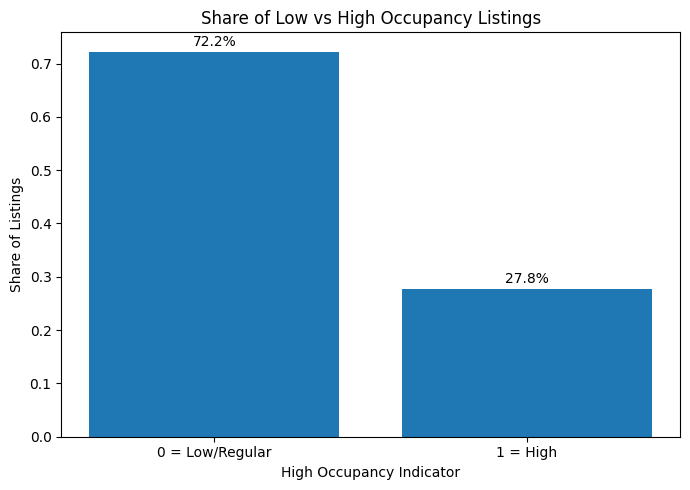

In [3]:
plt.figure(figsize=(7, 5))

plt.bar(target_share.index.astype(str), target_share.values)

plt.title("Share of Low vs High Occupancy Listings")
plt.xlabel("High Occupancy Indicator")
plt.ylabel("Share of Listings")
plt.xticks([0, 1], ["0 = Low/Regular", "1 = High"])

for i, v in enumerate(target_share.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.savefig(fig_path / "01_target_distribution.png", dpi=200)
plt.show()


## 3. Borough-Level EDA

We compare high-occupancy rates across NYC boroughs.


In [4]:
borough_summary = (
    df.groupby("neighbourhood_group_cleansed")
    .agg(
        listings=("id", "count"),
        high_occupancy_rate=("high_occupancy", "mean"),
        median_occupancy=("estimated_occupancy_l365d", "median"),
        avg_availability_365=("availability_365", "mean"),
        median_reviews=("number_of_reviews", "median")
    )
    .reset_index()
    .sort_values("high_occupancy_rate", ascending=False)
)

borough_summary


,neighbourhood_group_cleansed,listings,high_occupancy_rate,median_occupancy,avg_availability_365,median_reviews
4,Staten Island,369,0.349593,0.0,246.528455,10.0
3,Queens,5329,0.320886,0.0,180.855695,4.0
0,Bronx,1138,0.298770,0.0,212.579965,6.0
1,Brooklyn,13254,0.274860,0.0,155.185755,4.0
2,Manhattan,16355,0.262611,0.0,162.699175,2.0


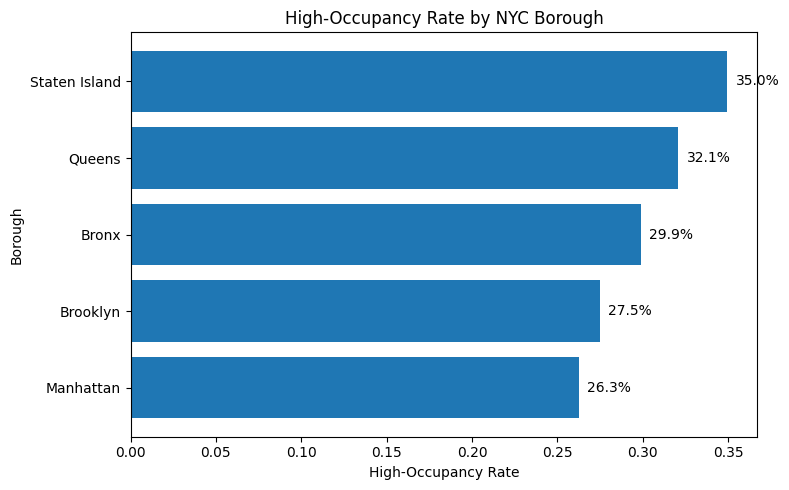

In [5]:
plot_data = borough_summary.sort_values("high_occupancy_rate", ascending=True)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["neighbourhood_group_cleansed"],
    plot_data["high_occupancy_rate"]
)

plt.title("High-Occupancy Rate by NYC Borough")
plt.xlabel("High-Occupancy Rate")
plt.ylabel("Borough")

for i, v in enumerate(plot_data["high_occupancy_rate"]):
    plt.text(v + 0.005, i, f"{v:.1%}", va="center")

plt.tight_layout()
plt.savefig(fig_path / "02_borough_high_occupancy_rate.png", dpi=200)
plt.show()


## 4. Room Type EDA

We compare occupancy patterns by room type.


In [6]:
room_summary = (
    df.groupby("room_type")
    .agg(
        listings=("id", "count"),
        high_occupancy_rate=("high_occupancy", "mean"),
        median_occupancy=("estimated_occupancy_l365d", "median"),
        median_minimum_nights=("minimum_nights", "median"),
        median_reviews=("number_of_reviews", "median")
    )
    .reset_index()
    .sort_values("high_occupancy_rate", ascending=False)
)

room_summary


,room_type,listings,high_occupancy_rate,median_occupancy,median_minimum_nights,median_reviews
0,Entire home/apt,19416,0.288576,0.0,30.0,3.0
3,Shared room,251,0.282869,0.0,30.0,1.0
2,Private room,16444,0.268365,0.0,30.0,3.0
1,Hotel room,334,0.089820,0.0,1.0,0.0


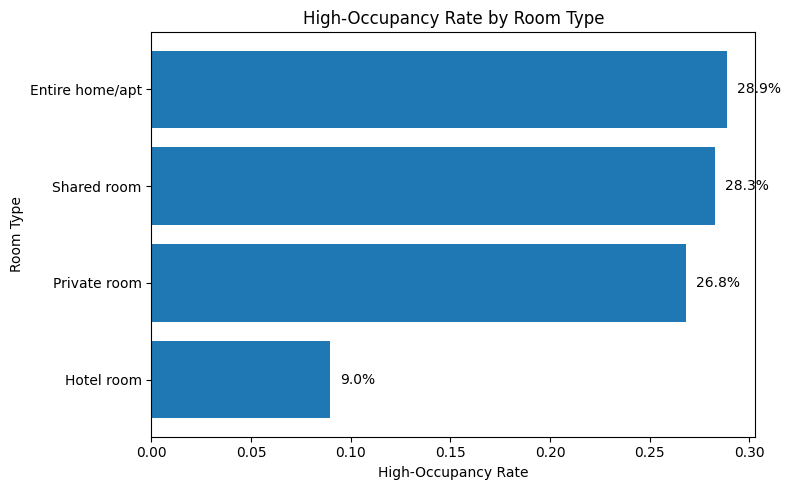

In [7]:
plot_data = room_summary.sort_values("high_occupancy_rate", ascending=True)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["room_type"],
    plot_data["high_occupancy_rate"]
)

plt.title("High-Occupancy Rate by Room Type")
plt.xlabel("High-Occupancy Rate")
plt.ylabel("Room Type")

for i, v in enumerate(plot_data["high_occupancy_rate"]):
    plt.text(v + 0.005, i, f"{v:.1%}", va="center")

plt.tight_layout()
plt.savefig(fig_path / "03_room_type_high_occupancy_rate.png", dpi=200)
plt.show()


## 5. Comparing High- and Low-Occupancy Listings

The plots below compare availability and review frequency across occupancy groups.


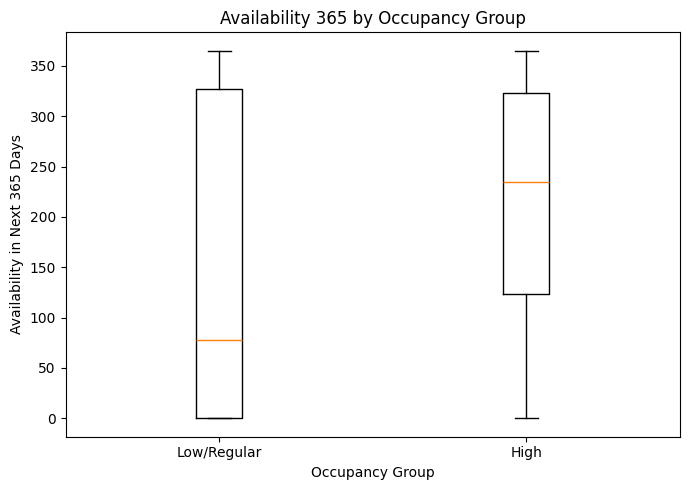

In [8]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df.loc[df["high_occupancy"] == 0, "availability_365"].dropna(),
        df.loc[df["high_occupancy"] == 1, "availability_365"].dropna()
    ],
    tick_labels=["Low/Regular", "High"],
    showfliers=False
)

plt.title("Availability 365 by Occupancy Group")
plt.xlabel("Occupancy Group")
plt.ylabel("Availability in Next 365 Days")

plt.tight_layout()
plt.savefig(fig_path / "04_availability_by_occupancy_group.png", dpi=200)
plt.show()


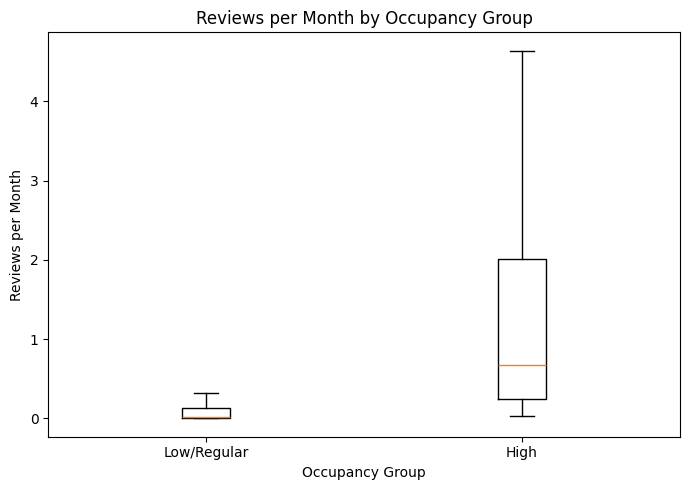

In [9]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df.loc[df["high_occupancy"] == 0, "reviews_per_month"].dropna(),
        df.loc[df["high_occupancy"] == 1, "reviews_per_month"].dropna()
    ],
    tick_labels=["Low/Regular", "High"],
    showfliers=False
)

plt.title("Reviews per Month by Occupancy Group")
plt.xlabel("Occupancy Group")
plt.ylabel("Reviews per Month")

plt.tight_layout()
plt.savefig(fig_path / "05_reviews_per_month_by_occupancy_group.png", dpi=200)
plt.show()


## 6. Spatial Visualization

This plot uses longitude and latitude to visualize the geographic spread of listings. A sample is used to keep the plot readable.


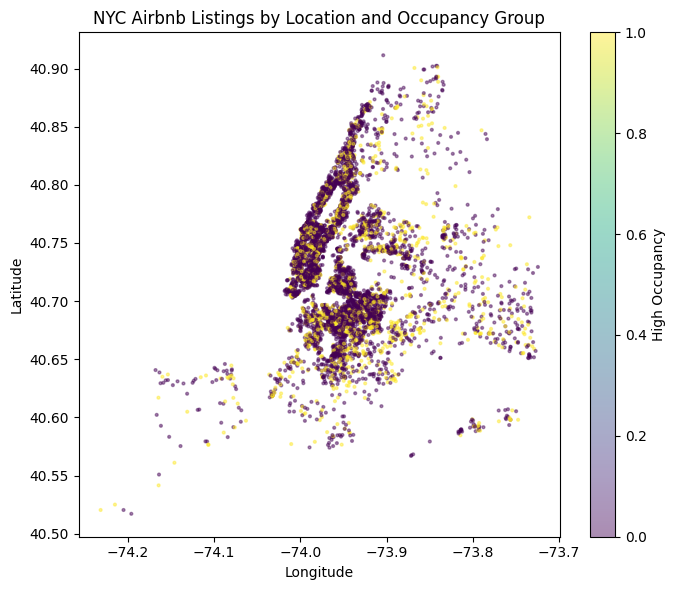

In [10]:
map_sample = df.sample(min(7000, len(df)), random_state=42)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    map_sample["longitude"],
    map_sample["latitude"],
    c=map_sample["high_occupancy"],
    s=4,
    alpha=0.45
)

plt.title("NYC Airbnb Listings by Location and Occupancy Group")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="High Occupancy")

plt.tight_layout()
plt.savefig(fig_path / "06_location_scatter_high_occupancy.png", dpi=200)
plt.show()


## 7. Correlation Analysis

We inspect correlations among selected numeric variables. This helps identify variables associated with the target and variables that may need special care in modeling.


In [11]:
corr_cols = [
    "high_occupancy",
    "estimated_occupancy_l365d",
    "availability_365",
    "minimum_nights",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms_count",
    "amenity_count",
    "name_length",
    "description_length"
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)
corr

,high_occupancy,estimated_occupancy_l365d,availability_365,minimum_nights,number_of_reviews,number_of_reviews_ltm,reviews_per_month,review_scores_rating,accommodates,bedrooms,beds,bathrooms_count,amenity_count,name_length,description_length
high_occupancy,1.000000,0.861561,0.220532,-0.295537,0.323776,0.354705,0.378511,0.114954,0.021991,-0.067078,0.005701,-0.016661,0.354247,0.043548,0.147039
estimated_occupancy_l365d,0.861561,1.000000,0.175925,-0.412811,0.423041,0.510068,0.504789,0.128622,0.026368,-0.062129,0.016611,-0.023626,0.349642,0.041657,0.140410
availability_365,0.220532,0.175925,1.000000,-0.051878,0.065816,0.067069,0.085525,-0.148167,0.091330,0.024734,-0.065757,0.094233,0.272642,0.027133,0.107217
minimum_nights,-0.295537,-0.412811,-0.051878,1.000000,-0.262018,-0.381330,-0.375165,-0.002262,-0.077727,0.034977,0.000221,0.022226,-0.159265,-0.025429,-0.032452
number_of_reviews,0.323776,0.423041,0.065816,-0.262018,1.000000,0.625164,0.754289,0.092904,0.020762,-0.040305,0.040525,-0.039056,0.232272,0.030093,0.085878
number_of_reviews_ltm,0.354705,0.510068,0.067069,-0.381330,0.625164,1.000000,0.895533,0.050312,0.019649,-0.030258,0.008158,-0.018940,0.142795,0.027393,0.063187
reviews_per_month,0.378511,0.504789,0.085525,-0.375165,0.754289,0.895533,1.000000,0.071295,0.036744,-0.031188,0.026623,-0.029016,0.200076,0.030920,0.074357
review_scores_rating,0.114954,0.128622,-0.148167,-0.002262,0.092904,0.050312,0.071295,1.000000,0.010897,-0.011415,0.067843,-0.020813,0.159110,0.005612,0.063228
accommodates,0.021991,0.026368,0.091330,-0.077727,0.020762,0.019649,0.036744,0.010897,1.000000,0.503493,0.533948,0.363204,0.188808,0.046811,0.042687
bedrooms,-0.067078,-0.062129,0.024734,0.034977,-0.040305,-0.030258,-0.031188,-0.011415,0.503493,1.000000,0.466107,0.489646,0.073412,0.079432,0.079590


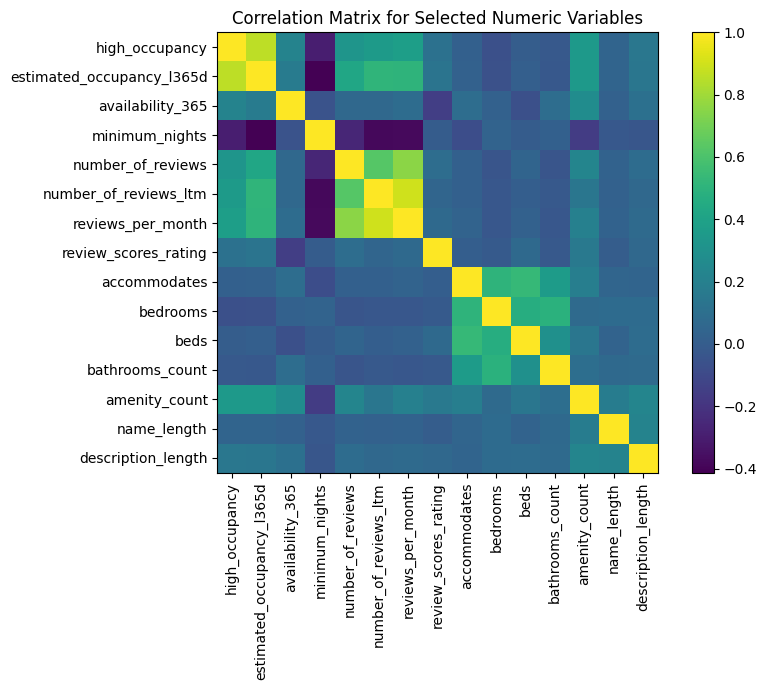

In [12]:
plt.figure(figsize=(9, 7))

im = plt.imshow(corr)
plt.title("Correlation Matrix for Selected Numeric Variables")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(im)

plt.tight_layout()
plt.savefig(fig_path / "07_numeric_correlation_matrix.png", dpi=200)
plt.show()


## 8. PCA Preparation

For unsupervised learning, we use numeric variables related to host characteristics, location, capacity, availability, reviews, and review scores.

We do **not** include `estimated_occupancy_l365d` or `high_occupancy` in clustering, because those are outcome variables.


In [13]:
cluster_features = [
    "hosts_time_as_host_years",
    "host_listings_count",
    "host_has_profile_pic",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_count",
    "bathroom_is_shared",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "calculated_host_listings_count",
    "amenity_count",
    "has_wifi",
    "has_kitchen",
    "name_length",
    "description_length"
]

cluster_features = [c for c in cluster_features if c in df.columns]

X_cluster = df[cluster_features].copy()

for col in X_cluster.columns:
    X_cluster[col] = pd.to_numeric(X_cluster[col], errors="coerce")
    median_value = X_cluster[col].median()
    X_cluster[col] = X_cluster[col].fillna(0 if pd.isna(median_value) else median_value)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Number of clustering features:", len(cluster_features))

Number of clustering features: 29


## 9. PCA

PCA gives us a two-dimensional view of listing structure before clustering.


In [14]:
pca = PCA(n_components=2, random_state=42)
pca_scores = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

df["pca1"] = pca_scores[:, 0]
df["pca2"] = pca_scores[:, 1]


Explained variance ratio:
[0.14599636 0.11517221]


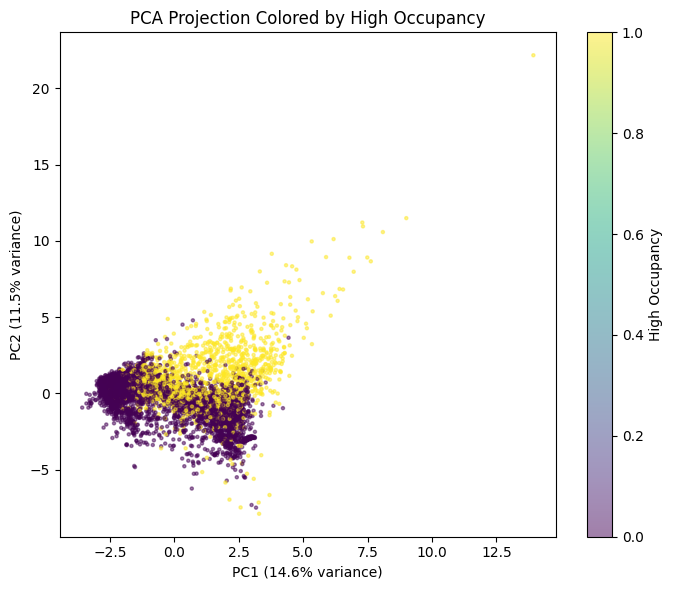

In [15]:
pca_sample = df.sample(min(7000, len(df)), random_state=42)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    pca_sample["pca1"],
    pca_sample["pca2"],
    c=pca_sample["high_occupancy"],
    s=5,
    alpha=0.5
)

plt.title("PCA Projection Colored by High Occupancy")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.colorbar(scatter, label="High Occupancy")

plt.tight_layout()
plt.savefig(fig_path / "08_pca_high_occupancy.png", dpi=200)
plt.show()


## 10. K-Means Elbow Method

We test k values from 2 to 8 and inspect the elbow plot.


In [16]:
ks = list(range(2, 9))
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "k": ks,
    "inertia": inertias
})

elbow_df


,k,inertia
0,2,929288.979561
1,3,863147.138780
2,4,811176.411501
3,5,770383.604408
4,6,734922.093728
5,7,702051.737206
6,8,679051.174084


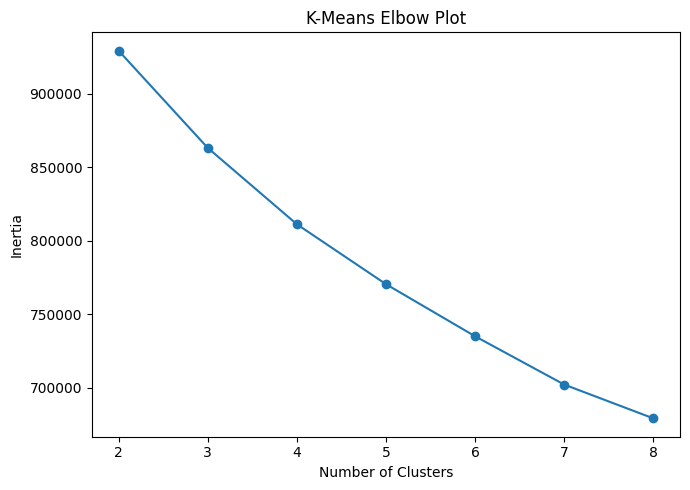

In [17]:
plt.figure(figsize=(7, 5))

plt.plot(elbow_df["k"], elbow_df["inertia"], marker="o")

plt.title("K-Means Elbow Plot")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.tight_layout()
plt.savefig(fig_path / "09_kmeans_elbow_plot.png", dpi=200)
plt.show()


## 11. Final K-Means Clustering

We use k = 4 because it provides an interpretable segmentation of listings without creating too many small clusters.


In [18]:
k_final = 4

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["listing_cluster"] = kmeans.fit_predict(X_scaled)

df["listing_cluster"].value_counts().sort_index()


listing_cluster
0     1541
1     2731
2    14491
3    17682
Name: count, dtype: int64

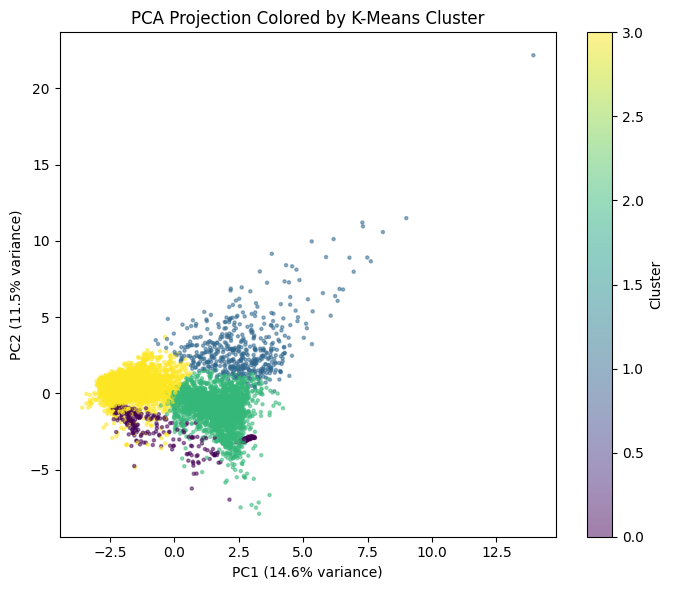

In [19]:
pca_sample = df.sample(min(7000, len(df)), random_state=42)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    pca_sample["pca1"],
    pca_sample["pca2"],
    c=pca_sample["listing_cluster"],
    s=5,
    alpha=0.5
)

plt.title("PCA Projection Colored by K-Means Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.savefig(fig_path / "10_pca_kmeans_clusters.png", dpi=200)
plt.show()


## 12. Cluster Profiles

We summarize each cluster to interpret the listing segments discovered by K-Means.


In [20]:
cluster_profile = (
    df.groupby("listing_cluster")
    .agg(
        listings=("id", "count"),
        high_occupancy_rate=("high_occupancy", "mean"),
        median_occupancy=("estimated_occupancy_l365d", "median"),
        median_availability_365=("availability_365", "median"),
        median_reviews=("number_of_reviews", "median"),
        median_reviews_per_month=("reviews_per_month", "median"),
        median_minimum_nights=("minimum_nights", "median"),
        median_accommodates=("accommodates", "median")
    )
    .reset_index()
    .sort_values("listing_cluster")
)

cluster_profile


,listing_cluster,listings,high_occupancy_rate,median_occupancy,median_availability_365,median_reviews,median_reviews_per_month,median_minimum_nights,median_accommodates
0,0,1541,0.031149,0.0,301.0,0.0,0.00,30.0,2.0
1,1,2731,0.970341,255.0,225.0,107.0,3.12,1.0,2.0
2,2,14491,0.286040,0.0,341.0,2.0,0.10,30.0,2.0
3,3,17682,0.185160,0.0,0.0,3.0,0.05,30.0,2.0


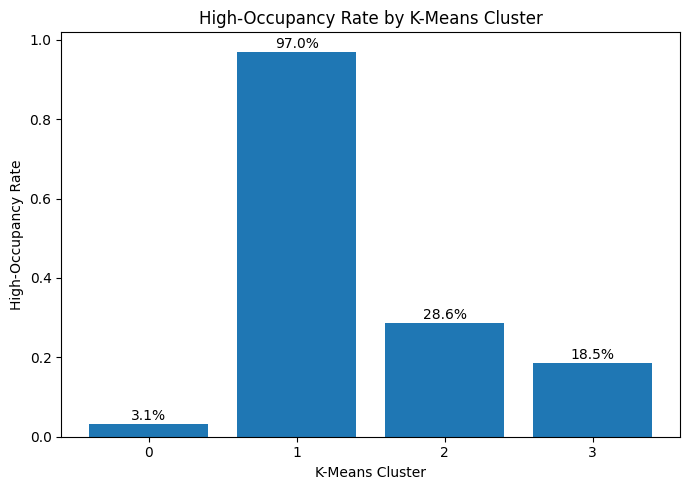

In [21]:
plt.figure(figsize=(7, 5))

plt.bar(
    cluster_profile["listing_cluster"].astype(str),
    cluster_profile["high_occupancy_rate"]
)

plt.title("High-Occupancy Rate by K-Means Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("High-Occupancy Rate")

for i, v in enumerate(cluster_profile["high_occupancy_rate"]):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.savefig(fig_path / "11_cluster_high_occupancy_rate.png", dpi=200)
plt.show()


## 13. Save Outputs

We save the clustered dataset and supporting tables for later modeling and reporting.


In [22]:
df.to_csv(processed_path / "nyc_airbnb_cleaned_with_clusters.csv", index=False)
cluster_profile.to_csv(processed_path / "cluster_profile.csv", index=False)
elbow_df.to_csv(processed_path / "kmeans_elbow_results.csv", index=False)

print("Saved clustered dataset and cluster profile.")


Saved clustered dataset and cluster profile.


## Summary

Main takeaways:

1. The high-occupancy class represents a meaningful minority of listings, making binary classification appropriate.
2. Occupancy patterns vary by borough and room type, suggesting that location and listing type are important features.
3. Availability and review activity differ between high- and low-occupancy listings.
4. PCA provides a low-dimensional view of listing structure.
5. K-Means clustering identifies listing segments with different high-occupancy rates, suggesting that unsupervised learning captures meaningful structure in the data.
